# Elo K-sensitivity (Brasileirão sample)

This notebook parses match results from text, computes final Elo rankings for multiple K values, then plots **only teams whose final rank changes** across K, annotating each point with the rank.

In [9]:
import re
import pandas as pd
import matplotlib.pyplot as plt


## 1) Input data

In [10]:
raw_text = """
1ª rodada
EC Vitória 2 x 0 Remo
Atlético-MG 2 x 2 Palmeiras
Coritiba 0 x 1 Bragantino
Internacional 0 x 1 Athletico-PR
Fluminense 2 x 1 Grêmio
Chapecoense 4 x 2 Santos
Corinthians 1 x 2 Bahia
São Paulo 2 x 1 Flamengo
Mirassol 2 x 1 Vasco da Gama
Botafogo 4 x 0 Cruzeiro

2ª rodada
Flamengo 1 x 1 Internacional
Bragantino 1 x 0 Atlético-MG
Santos 1 x 1 São Paulo
Remo 2 x 2 Mirassol
Palmeiras 5 x 1 EC Vitória
Grêmio 5 x 3 Botafogo
Bahia 1 x 1 Fluminense
Vasco da Gama 1 x 1 Chapecoense
Cruzeiro 1 x 2 Coritiba
Athletico-PR 0 x 1 Corinthians

3ª rodada
EC Vitória 1 x 2 Flamengo
Mirassol 2 x 2 Cruzeiro
Chapecoense 3 x 3 Coritiba
Atlético-MG 3 x 3 Remo
Vasco da Gama 0 x 1 Bahia
São Paulo 2 x 0 Grêmio
Athletico-PR 2 x 1 Santos
Fluminense 1 x 0 Botafogo
Corinthians 2 x 0 Bragantino
Internacional 1 x 3 Palmeiras
"""

# Tune these
k_values = [10, 20, 30, 40, 60]
hfa = 100


## 2) Team normalization (aliases)

In [11]:
ALIASES = {
    "Inter": "Internacional",
    "Bragantino": "Red Bull Bragantino",  # optional rename
}

def norm(team: str) -> str:
    team = team.strip()
    return ALIASES.get(team, team)


## 3) Parse matches from text

In [12]:
def parse_matches(text: str) -> pd.DataFrame:
    rows = []
    current_round = None

    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue

        m_round = re.match(r"(\d+)[ªa]*\s+rodada", line, flags=re.I)
        if m_round:
            current_round = int(m_round.group(1))
            continue

        m_game = re.match(r"(.+?)\s+(\d+)\s*x\s*(\d+)\s+(.+)", line)
        if m_game and current_round is not None:
            home = norm(m_game.group(1))
            hg = int(m_game.group(2))
            ag = int(m_game.group(3))
            away = norm(m_game.group(4))
            rows.append((current_round, home, away, hg, ag))

    df = pd.DataFrame(rows, columns=["Round", "Home", "Away", "hg", "ag"])
    df = df.sort_values(["Round"]).reset_index(drop=True)
    return df

matches = parse_matches(raw_text)
matches


,Round,Home,Away,hg,ag
0,1,EC Vitória,Remo,2,0
1,1,Atlético-MG,Palmeiras,2,2
2,1,Coritiba,Red Bull Bragantino,0,1
3,1,Internacional,Athletico-PR,0,1
4,1,Fluminense,Grêmio,2,1
5,1,Chapecoense,Santos,4,2
6,1,Corinthians,Bahia,1,2
7,1,São Paulo,Flamengo,2,1
8,1,Mirassol,Vasco da Gama,2,1
9,1,Botafogo,Cruzeiro,4,0


## 4) Elo functions

In [13]:
def update_elo(ratings: dict, home: str, away: str, hg: int, ag: int, k: float = 30, hfa: float = 100):
    rh, ra = ratings.get(home, 1500.0), ratings.get(away, 1500.0)
    expected_h = 1 / (1 + 10 ** ((ra - (rh + hfa)) / 400))
    expected_a = 1 - expected_h

    if hg > ag:
        sh, sa = 1.0, 0.0
    elif hg < ag:
        sh, sa = 0.0, 1.0
    else:
        sh, sa = 0.5, 0.5

    ratings[home] = rh + k * (sh - expected_h)
    ratings[away] = ra + k * (sa - expected_a)
    return ratings

def compute_elo_table(matches: pd.DataFrame, k: float = 30, hfa: float = 100) -> pd.DataFrame:
    ratings = {}
    for _, m in matches.iterrows():
        ratings = update_elo(
            ratings,
            home=m["Home"], away=m["Away"],
            hg=int(m["hg"]), ag=int(m["ag"]),
            k=k, hfa=hfa
        )

    df = pd.DataFrame(list(ratings.items()), columns=["Team", "Elo"])
    df = df.sort_values("Elo", ascending=False).reset_index(drop=True)
    df["Pos_Elo"] = df.index + 1
    return df[["Pos_Elo", "Team", "Elo"]]


## 5) Compute Elo positions across K

In [14]:
def elo_positions_by_k(matches: pd.DataFrame, k_values, hfa: float = 100) -> pd.DataFrame:
    rows = []
    for k in k_values:
        table_k = compute_elo_table(matches, k=k, hfa=hfa)
        for _, r in table_k.iterrows():
            rows.append({"Team": r["Team"], "K": k, "Pos_Elo": int(r["Pos_Elo"])})
    return pd.DataFrame(rows)

df_k = elo_positions_by_k(matches, k_values=k_values, hfa=hfa)
df_k.sort_values(["Team","K"]).head(20)


,Team,K,Pos_Elo
7,Athletico-PR,10,8
27,Athletico-PR,20,8
47,Athletico-PR,30,8
67,Athletico-PR,40,8
87,Athletico-PR,60,8
14,Atlético-MG,10,15
34,Atlético-MG,20,15
54,Atlético-MG,30,15
74,Atlético-MG,40,15
94,Atlético-MG,60,15


## 6) Plot only teams that change rank (annotate positions)

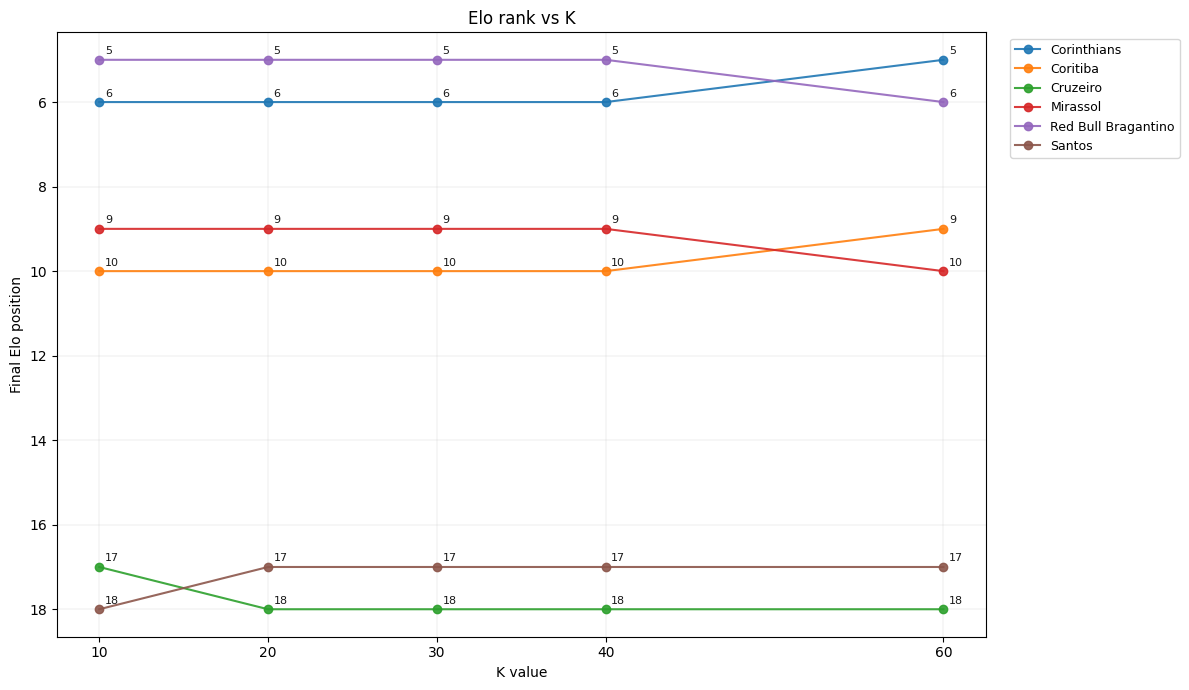


Position table:
K                    10  20  30  40  60
Team                                   
Corinthians           6   6   6   6   5
Coritiba             10  10  10  10   9
Cruzeiro             17  18  18  18  18
Mirassol              9   9   9   9  10
Red Bull Bragantino   5   5   5   5   6
Santos               18  17  17  17  17


In [15]:
def plot_only_changers_with_positions(df_long: pd.DataFrame, title: str = "Elo rank vs K"):
    r = df_long.groupby("Team")["Pos_Elo"].agg(["min", "max"])
    changers = r.index[r["min"] != r["max"]].tolist()
    dfc = df_long[df_long["Team"].isin(changers)].copy()

    if dfc.empty:
        print("No teams change position across the chosen K values.")
        return

    plt.figure(figsize=(12, 7))
    for team, g in dfc.groupby("Team"):
        g = g.sort_values("K")
        plt.plot(g["K"], g["Pos_Elo"], marker="o", linewidth=1.5, alpha=0.9, label=team)

        for _, row in g.iterrows():
            plt.annotate(
                str(int(row["Pos_Elo"])),
                xy=(row["K"], row["Pos_Elo"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                alpha=0.9,
            )

    plt.gca().invert_yaxis()
    plt.xticks(sorted(dfc["K"].unique()))
    plt.xlabel("K value")
    plt.ylabel("Final Elo position")
    plt.title(title)
    plt.grid(True, linewidth=0.3, alpha=0.5)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

    pivot = dfc.pivot(index="Team", columns="K", values="Pos_Elo").sort_index()
    print("\nPosition table:")
    print(pivot.to_string())

plot_only_changers_with_positions(df_k)


In [16]:
df_k.to_csv("elo_positions_by_k.csv", index=False, encoding="utf-8-sig")